In [30]:
import pandas as pd
import xarray as xr 
from dask_jobqueue import SLURMCluster

cluster = SLURMCluster(
    job_name="Climt1",          # --job-name
    cores=42,                   # 24 cores per node
    processes=1,                # One process per task
    memory="200GB",             # --mem
    walltime="04:00:00",        # --time
    queue="med",                # --partition
    log_directory=".",
         # Logs will be saved to the current directory
)

/home1/nalex2023/.conda/envs/nma/lib/python3.13/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 44187 instead
  warnings.warn(


In [31]:
from dask.distributed import Client


cluster.scale(jobs=1)
client = Client(cluster)
client

Connection method: Cluster object,Cluster type: dask_jobqueue.SLURMCluster
Dashboard: http://10.42.239.61:44187/status,
Dashboard: http://10.42.239.61:44187/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://10.42.239.61:37985,Workers: 0
Dashboard: http://10.42.239.61:44187/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [63]:
cluster.close()

In [64]:
client.shutdown()

In [32]:
import glob
import os

In [33]:
infol = '/home2/nalex2023/Datasets/ERA_global/u10_v10_era_single/'

in_dft = pd.DataFrame()

in_dft['filepath'] = glob.glob(infol + '*.nc')

in_dft['filename'] = in_dft['filepath'].str.split(os.sep).str[-1]

in_dft['var'] = in_dft['filename'].str.split('_').str[2]

in_dft[['year', 'month', 'day']] = in_dft['filename'].str.extract(r'(\d{4})_(\d{2})_(\d{2})')

in_dft['datetime'] = pd.to_datetime(in_dft[['year','month','day']])

in_dft

,filepath,filename,var,year,month,day,datetime
0,/home2/nalex2023/Datasets/ERA_global/u10_v10_e...,era5_pl_10u_2018_09_01.nc,10u,2018,09,01,2018-09-01
1,/home2/nalex2023/Datasets/ERA_global/u10_v10_e...,era5_pl_10u_2017_09_01.nc,10u,2017,09,01,2017-09-01
2,/home2/nalex2023/Datasets/ERA_global/u10_v10_e...,era5_pl_10v_2013_11_01.nc,10v,2013,11,01,2013-11-01
3,/home2/nalex2023/Datasets/ERA_global/u10_v10_e...,era5_pl_10v_2005_04_01.nc,10v,2005,04,01,2005-04-01
4,/home2/nalex2023/Datasets/ERA_global/u10_v10_e...,era5_pl_10u_2000_08_01.nc,10u,2000,08,01,2000-08-01
...,...,...,...,...,...,...,...
499,/home2/nalex2023/Datasets/ERA_global/u10_v10_e...,era5_pl_10v_2001_05_01.nc,10v,2001,05,01,2001-05-01
500,/home2/nalex2023/Datasets/ERA_global/u10_v10_e...,era5_pl_10u_2011_01_01.nc,10u,2011,01,01,2011-01-01
501,/home2/nalex2023/Datasets/ERA_global/u10_v10_e...,era5_pl_10u_2013_08_01.nc,10u,2013,08,01,2013-08-01
502,/home2/nalex2023/Datasets/ERA_global/u10_v10_e...,era5_pl_10v_2017_10_01.nc,10v,2017,10,01,2017-10-01


In [34]:
#in_dft_test_u = in_dft[(in_dft['datetime'].dt.year == 2018) & (in_dft['var'] == '10u')]

#in_dft_test_v = in_dft[(in_dft['datetime'].dt.year == 2018) & (in_dft['var'] == '10v')]

#in_dft_test = in_dft[(in_dft['datetime'].dt.year == 2001) & (in_dft['datetime'].dt.month.isin([1,2,3,4,5,6]))]

#v_data_test = 

In [35]:
in_dft_sorted = in_dft.sort_values('filename')

in_dft_sorted_sub = in_dft_sorted[in_dft_sorted['year'].isin(np.arange(2000,2016).astype(str))]



In [17]:
import numpy as np
import flox.xarray


In [37]:
#data_test['speed'] = np.sqrt(np.square(data_test['VAR_10U']) + np.square(data_test['VAR_10V']))

In [18]:
def process_era_data(year, month, in_dft):
    """
    Process ERA5 data for a specific year and month to compute diurnal cycle
    
    Parameters:
    -----------
    year : int
        Year to process
    month : int  
        Month to process
    in_dft : pd.DataFrame
        DataFrame containing file paths and metadata
        
    Returns:
    --------
    diurnal_final : xr.Dataset
        Computed diurnal cycle dataset
    """
    
    # Filter data for specified year and month
    in_dft_test = in_dft[(in_dft['datetime'].dt.year == year) & (in_dft['datetime'].dt.month == month)]
    
    # Open dataset
    data_test = xr.open_mfdataset(in_dft_test['filepath'], combine_attrs='drop').drop_vars('utc_date')
    
    # Chunk the data
    data_test = data_test.chunk({"time": -1, "longitude": 100, "latitude": 200})
    
    # Calculate local solar time
    times = data_test['time']
    lons = data_test['longitude']
    
    times = times.astype('datetime64[h]')
    times2d, lons2d = xr.broadcast(times, lons)
    time_shift = (lons2d / 15).astype('timedelta64[h]')
    lst_time = times2d + time_shift
    lst_time_hours = lst_time.dt.hour
    
    # Assign LST coordinates
    data_test = data_test.assign_coords(lst_hour=(("time", "longitude"), lst_time_hours.data))
    
    # Compute diurnal cycle
    diurnal_cycle = data_test.groupby("lst_hour").mean(dim="time", engine='flox')
    diurnal_cycle = diurnal_cycle.chunk({"lst_hour": -1, "longitude": 721, "latitude": 1400})
    diurnal_final = diurnal_cycle.compute()
    
    # Save to file
    output_path = f'/home2/nalex2023/Datasets/ERA_global/u10_v10_era_single/procesed_diurnal/{year:04d}{month:02d}_u10_v10.nc'
    diurnal_final.to_netcdf(output_path)
    
    print(f"Processed and saved data for {year}-{month:02d} to {output_path}")
    
    return diurnal_final

In [ ]:
# Example usage of the function
year = 2
month = 1

# Process the data using the function
diurnal_final = process_era_data(year, month, in_dft)

/home1/nalex2023/.conda/envs/nma/lib/python3.13/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 10.34 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


FutureCancelledError: ('rechunk-merge-7e0b463398256c64484cd03a7d5c9847', 0, 0, 0) cancelled for reason: scheduler-connection-lost.
Client lost the connection to the scheduler. Please check your connection and re-run your work.

In [59]:
# Process multiple months/years
# Example: Process different months
year =2000
for month in [1, 2, 3, 4, 5, 6, 7,8,9,10,12]:
    
    diurnal_data = process_era_data(year, month, in_dft)
    print(f'finished {month}-{year}')
    # You can now work with diurnal_data for each month

# Or process a different year
# diurnal_2003 = process_era_data(2003, 6, in_dft)


/home1/nalex2023/.conda/envs/nma/lib/python3.13/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 10.34 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


FutureCancelledError: ('rechunk-merge-8ca2a8b3b11e392da3aabeb131750e03', 0, 1, 0) cancelled for reason: scheduler-connection-lost.
Client lost the connection to the scheduler. Please check your connection and re-run your work.

In [20]:
diurnal_final.to_netcdf('/home2/nalex2023/Datasets/ERA_global/u10_v10_era_single/procesed_diurnal/200107_u10_v10.nc')

NameError: name 'diurnal_final' is not defined

In [15]:
os.mkdir('/home2/nalex2023/Datasets/ERA_global/u10_v10_era_single/procesed_diurnal/')

In [8]:
diurnal_final = xr.open_dataset('/home2/nalex2023/Datasets/ERA_global/u10_v10_era_single/procesed_diurnal/200101_u10_v10.nc')

In [9]:
import numpy as np

In [10]:


diurnal_final['speed'] = np.sqrt(np.square(diurnal_final['VAR_10U']) + np.square(diurnal_final['VAR_10V']))



In [11]:
import matplotlib.pyplot as plt

import cartopy.crs as ccrs 
import cartopy.feature as cfeature



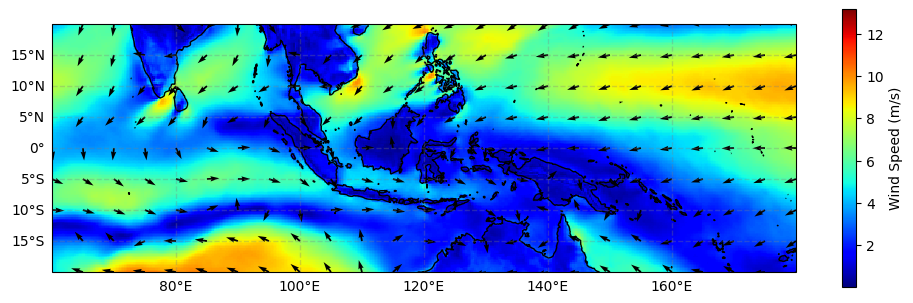

In [ ]:
fig,ax = plt.subplots(figsize=(12,6),subplot_kw={'projection':ccrs.PlateCarree()})

winds_mon_eve = diurnal_final.sel(lst_hour=[9,10,11,14,15,16,17]).mean(dim='lst_hour')

winds_mon = diurnal_final.sel(lst_hour=[9,10,11]).mean(dim='lst_hour')

winds_eve = diurnal_final.sel(lst_hour=[2,3,4,5]).mean(dim='lst_hour')

winds_diff = winds_mon - winds_eve

sp_col = winds_mon_eve['speed'].plot(ax=ax,transform=ccrs.PlateCarree(),cmap='jet',add_colorbar=False)


gl = ax.gridlines(draw_labels=True, linewidth=1, alpha=0.3, linestyle='--', color='gray')

gl.top_labels = False
gl.right_labels = False


ax.coastlines()
ax.set_extent([60,180,-20,20],crs=ccrs.PlateCarree())
ax.stock_img()

# quiver plot

mag_new = np.sqrt(winds_mon_eve['VAR_10U']**2 + winds_mon_eve['VAR_10V'] ** 2)


x_vals = winds_mon_eve['longitude'][::20]
y_vals = winds_mon_eve['latitude'][::20]
u_vals = winds_mon_eve['VAR_10U'][::20,::20]
v_vals = winds_mon_eve['VAR_10V'][::20,::20]


epsilon = 1e-6

u_norm = u_vals / (mag_new + epsilon)
v_norm = v_vals / (mag_new + epsilon)



ax.quiver(x_vals,y_vals,u_norm,v_norm,transform=ccrs.PlateCarree(),scale=60,color='black')

# add custom colorbar for wind speed

cbar = plt.colorbar(sp_col, ax=ax, orientation='vertical', shrink=0.6)
cbar.set_label('Wind Speed (m/s)')


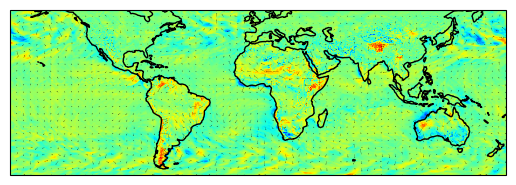

In [9]:
fig,ax = plt.subplots(subplot_kw={'projection':ccrs.PlateCarree()})

ax.coastlines()
ax.set_extent([-180,180,-60,60])
ax.add_feature(cfeature.LAND)

winds_diff['speed'].plot(ax=ax,transform=ccrs.PlateCarree(),cmap='jet',add_colorbar=False)


x_vals = winds_diff['longitude'][::20]
y_vals = winds_diff['latitude'][::20]
u_vals = winds_diff['VAR_10U'][::20,::20]
v_vals = winds_diff['VAR_10V'][::20,::20]

ax.quiver(x_vals,y_vals,u_vals,v_vals,transform=ccrs.PlateCarree(),scale=200,
          headwidth=4,headlength=3,width=0.0004)


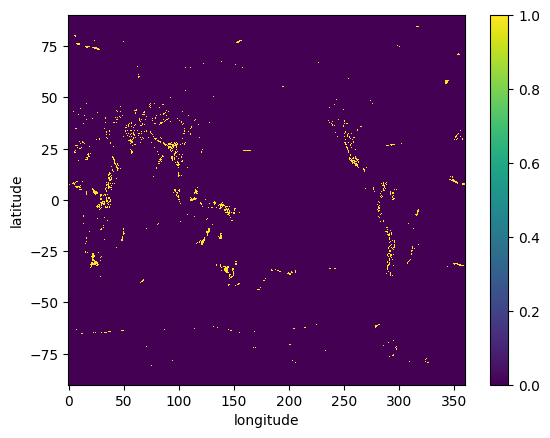

In [10]:
import math

dot_product = winds_mon['VAR_10U'] * winds_eve['VAR_10U'] + winds_mon['VAR_10V'] * winds_eve['VAR_10V']
mag_dot_pro = np.sqrt(winds_mon['VAR_10U']**2 + winds_mon['VAR_10U']**2) * np.sqrt(winds_mon['VAR_10V']**2 + winds_mon['VAR_10V']**2)
cos_theta = dot_product / mag_dot_pro


angle = np.arccos(np.clip(cos_theta, -1, 1))

threshold = math.radians(150)                  # 150°

reversal_points = angle > threshold
reversal_points.plot()


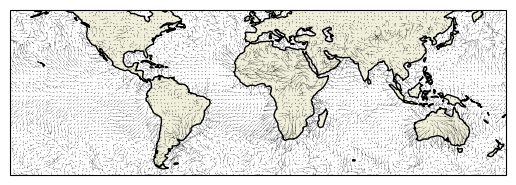

In [11]:
fig,ax = plt.subplots(subplot_kw={'projection':ccrs.PlateCarree()})


morn_min_eve = diurnal_final.sel(lst_hour=[9,10,11,12]).mean(dim='lst_hour') - diurnal_final.sel(lst_hour=[14,15,16,17]).mean(dim='lst_hour')


ax.coastlines()
ax.set_extent([-180,180,-60,60])
ax.add_feature(cfeature.LAND)

# quiver plot

x_vals = morn_min_eve['longitude'][::10]
y_vals = morn_min_eve['latitude'][::10]
u_vals = morn_min_eve['VAR_10U'][::10,::10]
v_vals = morn_min_eve['VAR_10V'][::10,::10]

ax.quiver(x_vals,y_vals,u_vals,v_vals,transform=ccrs.PlateCarree(),scale=100,
          headwidth=4,headlength=4
          ,width=0.0004)


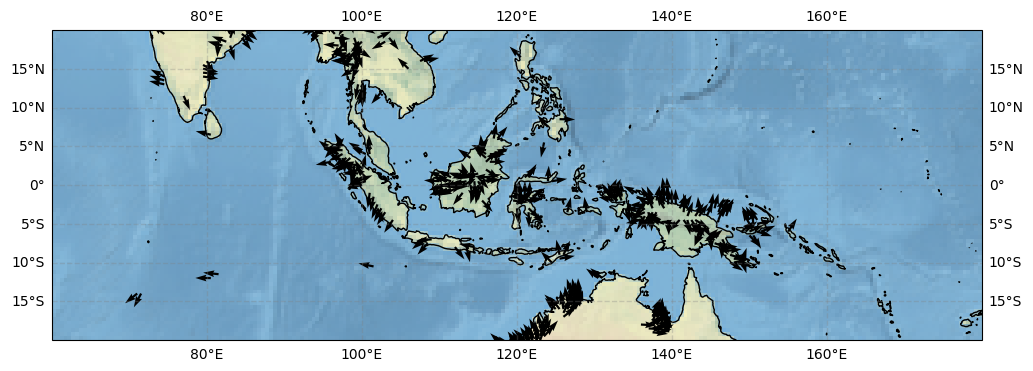

In [22]:
from cartopy.io.img_tiles import GoogleTiles


fig,ax = plt.subplots(figsize=(12,6),subplot_kw={'projection':ccrs.PlateCarree()})


morn_min_eve = diurnal_final.sel(lst_hour=[9,10,11,12]).mean(dim='lst_hour') - diurnal_final.sel(lst_hour=[14,15,16,17]).mean(dim='lst_hour')


morn_min_eve_fil = morn_min_eve.where(reversal_points,np.nan)

mag_new = np.sqrt(morn_min_eve_fil['VAR_10U']**2 + morn_min_eve_fil['VAR_10V'] ** 2)

ax.coastlines()
ax.set_extent([60,180,-20,20],crs=ccrs.PlateCarree())
ax.stock_img()

gl = ax.gridlines(draw_labels=True, linewidth=1, alpha=0.3, linestyle='--', color='gray')


x_vals = morn_min_eve_fil['longitude'][::2]
y_vals = morn_min_eve_fil['latitude'][::2]
u_vals = morn_min_eve_fil['VAR_10U'][::2,::2]
v_vals = morn_min_eve_fil['VAR_10V'][::2,::2]

epsilon = 1e-6

u_norm = u_vals / (mag_new + epsilon)
v_norm = v_vals / (mag_new + epsilon)


ax.quiver(x_vals,y_vals,u_norm,v_norm,transform=ccrs.PlateCarree(),scale=60,color='black') 

